# 02 - Features

## Imports

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage.feature import hog
from skimage import exposure
import os

# Make sure we get outputs from a probabilitistic model each time (for reproducibility) 
np.random.seed(1515)

## Basic Image Pre-processing

### What is Pre-processing? 

**Pre-processing** is the process of changing an image so that it is more suited for analysis/model-building. 

For example, in our FRC 2026 REBUILT ball-detection task, some things that would probbably make detection is to make the balls stand out in the image more so the model picks up on them. 

Pre-processing lets us do that. We will be showing what this pre-processing by demoing the individual techniques.

To operationalize this, let us use an image of yellow balls on the field:

![](./ref_imgs/balls_on_field.png)

#### Grayscale

Grayscaling an image involves taking away the color channels so that our model is only in shades of black and white. Mathematically, you can think of it as reducing our matrix from a higher dimension representation with the 3 color channels to simply having the height and width representation. 

Let's see what this looks like on our image: 

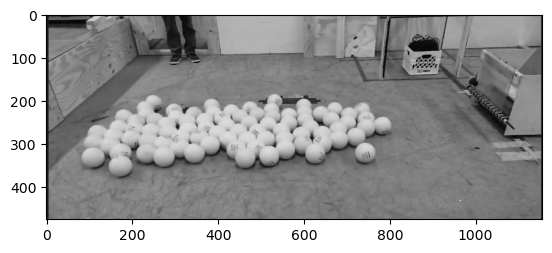

In [155]:
# Read the color image
img_bgr = cv2.imread('./ref_imgs/balls_on_field.png') # by default reads in as BGR, not RGB 

# Convert the image to grayscale
img_grayscale = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Display our new grayscale image 
plt.imshow(img_grayscale, cmap = 'gray')
plt.show()

You might be wondering what the point of grayscaling an image is. Consider that if we had color in our image, and we trained our algorithm, our algorithm might associate being yellow with being a ball. While in our confined space, where we have no other yellow objects, this might work, consider if there was a yellow robot on our field. Our detection might get confused! 

However, if we remove color, our detection has to use other features to decide what a ball is, and will perform better at ball detection. Feel free to dive into all the literature surrounding best pre-processing for object detection (fair warning: it is dense reading!), and you will find empirical evidence for this claim. 

We will dive into what those features could be after pre-processing is done. 

#### Blurring

**Blurring** or **Smoothing** is another common pre-processing technique. Admittedly, this one might seem a bit confusing - why would we want our image quality to be *worse*? 

Looking at our image above, we can see that there are some small spots on the image, or texts on the ball, that would really only serve as a "distraction" to our image. By blurring the image, we smooth over these rapid changes in pixels and make sure our image only consists of the key features like the balls, or the wall. 

Let's see what this looks like: 

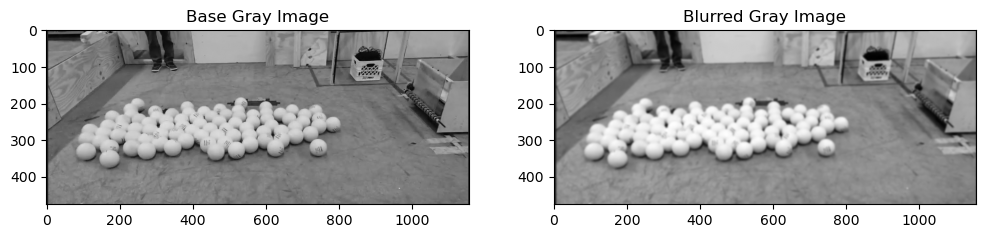

In [113]:
# apply the blur to the image 
img_blurred = cv2.GaussianBlur(img_grayscale, (11, 11), 0) # (11, 11) denotes kernel size, 0 is automatic SD detection 

# plot basic gray vs. blurred image 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

ax[0].imshow(img_grayscale, cmap = 'gray')
ax[0].set_title('Base Gray Image')

ax[1].imshow(img_blurred, cmap = 'gray')
ax[1].set_title('Blurred Gray Image')

plt.show()

Note that in the code we specify kernel size and another argument of standard deviation (SD) in the X dimension. We will cover some of the basics of kernels in our discussion of convolution with regards to neural networks.

#### De-Noising

Besides general blurring, we can **de-noise** our image to spot-remove any noise in the image. "Noise" is like what we talked about above - anything that might distract from the main parts of the image we want to focus on. 

De-noising, especially when using more complex algorithms, tends to be a lot more effective than simply blurring because it also works towards enhancing relevant features. Again, understanding how these algorithms work is not as important (and well beyond the scope of robotics), but it is key to understand what it is they are doing to better understand how it can give us better data. 

Let's look at what this denoising could be: 

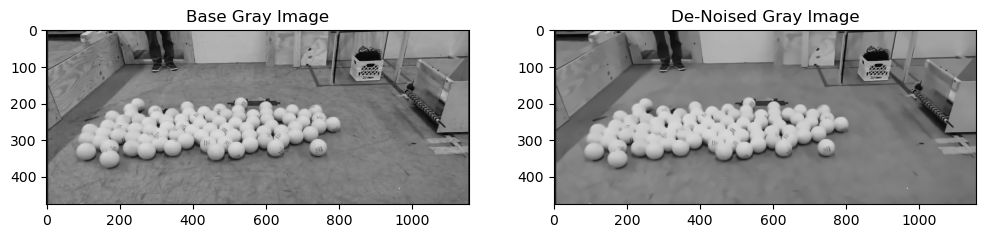

In [115]:
# Parameters are:
    # src: Input image (grayscale)
    # dst: Output image (None, as it's returned by the function)
    # h: Filter strength (higher value removes more noise but also more details; 10 is a good default)
    # templateWindowSize: Size of the template patch (must be odd; recommended 7)
    # searchWindowSize: Size of the search window (must be odd; recommended 21)

img_denoised = cv2.fastNlMeansDenoising(img_grayscale, None, h=10, templateWindowSize=7, searchWindowSize=21)

# plot basic gray vs. de-noised image 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

ax[0].imshow(img_grayscale, cmap = 'gray')
ax[0].set_title('Base Gray Image')

ax[1].imshow(img_denoised, cmap = 'gray')
ax[1].set_title('De-Noised Gray Image')

plt.show()

We can see that compared to our basic blurring, we get an image that does a better job of making the balls stand out by blurring the floor without adding as much blur to the balls. 

For those who are curious, this algorithm is called Non-local Means Denoising, which essentially denoises by using the average pixel value in a neighborhood of pixels based on their similarity.

#### Brightness Adjustment 

**Brightness** is basically just intensity that we mentioned in our first notebook; the higher the value, the stronger the color, with values towards 0 meaning stronger black shade and values towards 255 meaning stronger white shade.

Brightness can be a helpful tool in making sure our features of interest are more "visible" to our model - this is especially helpful if our image was underexposed. It can also be helpful if our image was overexposed and our features of interest cannot be discerned. 

Let's see what this looks like:

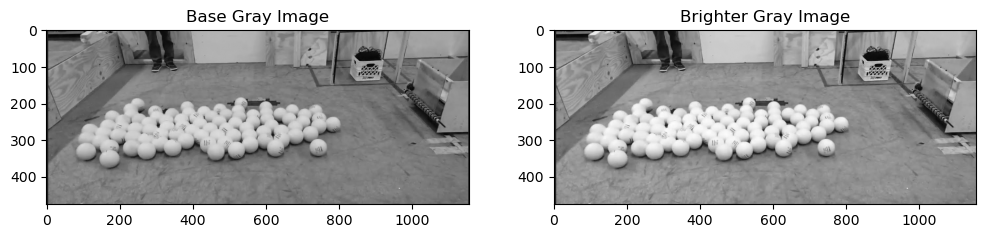

In [119]:
img_bright = cv2.convertScaleAbs(img_grayscale, alpha=1.0, beta=50) # alpha is our contrast value, beta our brightness value

# plot basic gray vs. brighter image 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

ax[0].imshow(img_grayscale, cmap = 'gray')
ax[0].set_title('Base Gray Image')

ax[1].imshow(img_bright, cmap = 'gray')
ax[1].set_title('Brighter Gray Image')

plt.show()

Now, our balls are slightly more visible. 

Note that we keep `alpha` = 1.0 to not change the contrast of our image, while `beta` changes our brightness (higher values mean more brightness). 

#### Contrast Adjusment

Naturally, we cover contrast adjustment next.

**Contrast** is defined as the difference between the lightest and darkest part of an image. This typically is what makes features of an image stand out - think of looking at a picture of a black t-shirt against a white background vs. a dark-gray background. 

In our case, contrast will again help the balls become more obvious to our detection model.

Let's see what that looks like: 

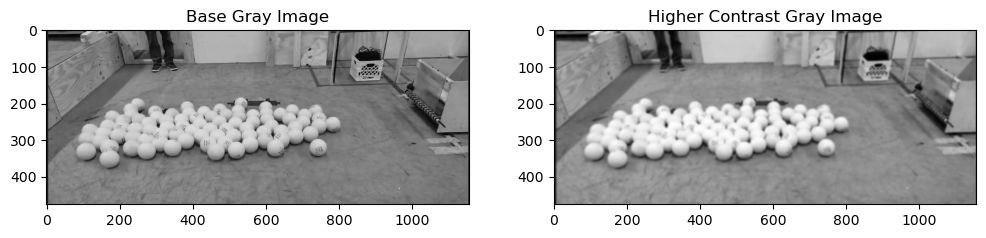

In [121]:
contrast_img = cv2.convertScaleAbs(img_grayscale, alpha=3.0, beta=0) # no brightness change, just contrast

# plot higher contrast vs. basic gray image 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

ax[0].imshow(img_grayscale, cmap = 'gray')
ax[0].set_title('Base Gray Image')

ax[1].imshow(img_blurred, cmap = 'gray')
ax[1].set_title('Higher Contrast Gray Image')

plt.show()

Note that sometimes, it can be a little difficult to discern between brightness and contrast changes. This is not surprising because contrast can involve some changes in localized brightness (certain areas are more/less bright). 

#### Other Pre-Processing

There are beyond dozens of different pre-processing techniques that you can use, from masking/thresholding to histogram equalization, among others. 

Feel free to research more, since we may use them at some point, but really the point here is for you to gain an understanding of how we can manipulate images to better serve our goals.

### How to Pick the best Pre-Processing Techniques

We naturally want to combine pre-processing techniques to give us the best possible images - but how do we pick what works best? 

Recall when we were going over our intro to ML, we discussed hyperparameter tuning, where we would essentially do a structured guess-and-check to determine the model parameters. 

For images, we do the exact same thing - we decide on hyperparameters to change (e.g., brighness level or contrast level), create a grid of possible values, and evaluate performance based on those values. 

In the case of images, the model that we evaluate against is going to depend on our task. If our goal is object ball detection, we pick a model that does ball detection, and pick the hyperparameters for image pre-processing that give us the best results.

## Features for Images

In the ML primer, we skipped over a discussion of features and how we select them, create them, etc. We will discuss features briefly for the sake of forming a foundation of understanding how features impact our vision-processing capabilities. 

### Traditional ML Features

In a traditional ML context, features are thought of as numeric representations of different variables that we use to predict/categorize our variable of interest. For instance, with our AP Calculus example, our features are fairly easy to think about as numbers: hours studied. 

If we expanded the model, we could go further into quantifying different variables that might influence exam scores. Some of them would be pretty straightforward, like hours of sleep the night before an exam, or your previous exam scores. There are some that would be more complicated to operationalize into models, like the effect of having a good study partner, or how a bad game during basketball ruined your mood and therefore you got a worse score. However, you can still imagine that the effects of the first feature are good, and the second are bad. 

At the end of the day, we can imagine them fairly intuitively.

But what about images - how do we process features for something visual? 

### Image Features

As mentioned in our first notebook, images are matrices/grids of numbers. It stands to reason that the features will be subsets, or smaller parts, of these grids. 

But what are those grids meant to represent? 

#### Edges

An **edge** in an image is usually defined as any area in an image that undergoes a rapid change in intensity. The magnitude and direction of the intensity change is known as a **gradient**. We recall from our previous notebook that intensity is our value that is encoded in the grid, and dictates how "strong" a color is. 

Let's look at what some edges could look like on our ball image:

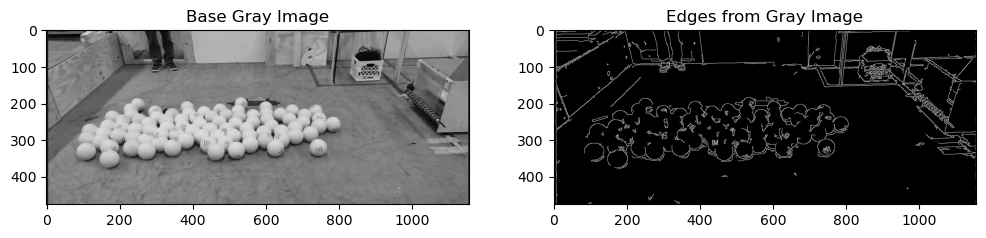

In [145]:
edges = cv2.Canny(img_grayscale, 50, 150)

# plot edges vs. basic gray image 

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))

ax[0].imshow(img_grayscale, cmap = 'gray')
ax[0].set_title('Base Gray Image')

ax[1].imshow(edges, cmap = 'gray')
ax[1].set_title('Edges from Gray Image')

plt.show()

We use Canny edge detection, a famous edge-detection algorithm (again, feel free to research the math behind this, but it is not necessary for understanding what it does). 

As you can see, the edges tend to give us a pretty good idea of the image we are looking at. This is a big reason that edges are considered among the foundational image features, and are still used heavily with more complex classification and object detection techniques. 

To think about why this would be more important than something like color, go back to our conversation about our FRC 2026 REBUILT object detection task of detecting the yellow balls in the field. If our field has any other yellow objects, then our classifier might struggle to determine what is a ball because it is focusing on finding color, whereas a classifier that relies on edges would simply find the edges that match a ball (e.g., the roundness). 

#### Color Histograms

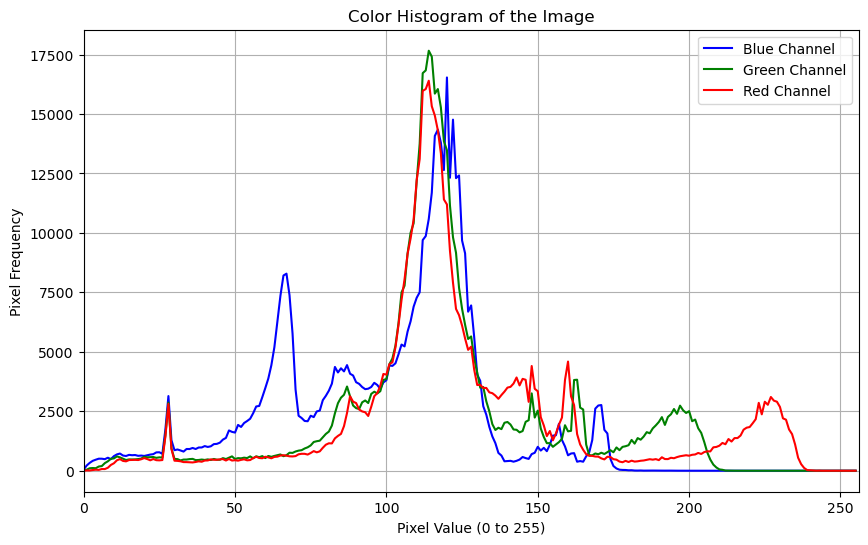

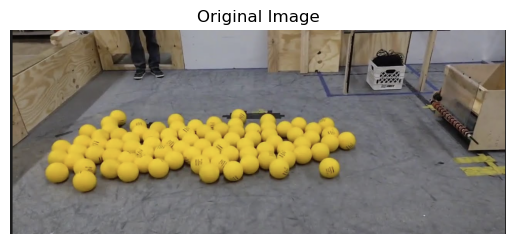

In [159]:
# Step 3: Calculate histograms for each channel
# Parameters for cv2.calcHist: [images], [channels], mask, [histSize], [ranges]
blue_hist = cv2.calcHist([img_bgr], [0], None, [256], [0, 256])
green_hist = cv2.calcHist([img_bgr], [1], None, [256], [0, 256])
red_hist = cv2.calcHist([img_bgr], [2], None, [256], [0, 256])

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Step 4: Plot the histograms
plt.figure(figsize=(10, 6))

# Plot each channel's histogram as a line graph for clarity
plt.plot(blue_hist, color='blue', label='Blue Channel')
plt.plot(green_hist, color='green', label='Green Channel')
plt.plot(red_hist, color='red', label='Red Channel')

plt.title('Color Histogram of the Image')
plt.xlabel('Pixel Value (0 to 255)')
plt.ylabel('Pixel Frequency')
plt.xlim([0, 256])
plt.legend()
plt.grid(True)
plt.show()

# Optional: Display the original image using Matplotlib
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')
plt.show()

This color histogram is a common way to map out color distributions, if color is relevant in our detection goals. In FRC 2026 REBUILT, it is not, so we will not discuss color as much, but it is still something good to have some understanding of for future applications. 

#### Other Features

Many of the other common features in computer vision, like Histograms of Oriented Gradients (HOGS), Pyramids, etc. all build on the foundational concept of gradients and edges. You can look into these features if you want, but the most important takeaway is the importance of edges and gradients in understanding where objects are within an image. 

Now, that we've covered the basics of features, we can move into a very powerful technique for classification: neural networks! 